
# Group 8 — Agriculture & Food Security
## Solavise Women in Data Programme | Week 8 Hackathon

**Dataset:** Crop Production in India | **Source:** Kaggle

---

## Group Contribution

| Member | Section |
|---|---|
| Nancy Yeboah & Jephtahlyn Attoh  | Data Cleaning, Coordination, Review |
| Jephtahlyn Attoh & Nancy Yeboah | NumPy & Pandas Analysis |
| Barihama Ayisha & Jephtahlyn Attoh | Data Visualization |
| Jephtahlyn Attoh & Nancy Yeboah | Machine Learning & Evaluation |
| Jephtahlyn Attoh | Storytelling & Presentation |


In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\dell\Downloads\crop_production.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 13.1 MB


Each row represents one farmer's report, which tells us where(State_Name/District_Name), what season, which year, what crop, the area of land and amount of products harvested.

In [ ]:
rows, columns = df.shape
print(f"The dataset has {rows} rows and {columns} columns.")
df.head()

The dataset has 246091 rows and 7 columns.


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [5]:
df.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [ ]:
df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Only one column has missing values. Production has 3,730 missing values.

In [ ]:
missing_pct = (df['Production'].isnull().sum() / len(df)) * 100
print(f"Missing Production values: {missing_pct:.2f}%")

Missing Production values: 1.52%


In [ ]:
# Drop rows where Production is missing
# Reasoning: Production is our key outcome variable.
# Without it the row provides no learnable pattern for the model.
df = df.dropna(subset=['Production'])

# Confirm
print(df.isnull().sum())
print(f"Remaining rows: {len(df)}")

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64
Remaining rows: 242361


### Zero production values (1.45% of data) likely reflect data entry errors rather than genuine crop failures. They contribute no useful pattern for yield analysis and would mislead our model.

In [ ]:
# How many rows have Production = 0?
zero_production = df[df['Production'] == 0]
print(f"Rows with zero production: {len(zero_production)}")
print(f"Percentage of dataset: {(len(zero_production)/len(df))*100:.2f}%")

# Which crops are most affected?
print(zero_production['Crop'].value_counts().head(10))

Rows with zero production: 3523
Percentage of dataset: 1.45%
Crop
Other Vegetables      286
Other Fresh Fruits    257
Pome Fruit            128
Citrus Fruit          121
Bhindi                119
Brinjal               119
Mango                 114
Cabbage               107
Cauliflower           104
Sesamum                97
Name: count, dtype: int64


In [ ]:
# Remove rows where Production is 0
# Reasoning: A Production value of 0 likely reflects data entry issues
# rather than genuine zero-yield harvests, and provides no learnable
# pattern for yield analysis. At only 1.45% of the dataset, removing
# them has minimal impact.
df = df[df['Production'] > 0]

print(f"Remaining rows: {len(df)}")
print(f"New dataset shape: {df.shape}")

Remaining rows: 238838
New dataset shape: (238838, 7)


In [ ]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [ ]:
# Check unique values in Season column
print(df['Season'].unique())

<StringArray>
['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ',
 'Winter     ']
Length: 6, dtype: str


The Season column contained trailing whitespace (e.g. 'Kharif     ') which Python treats as a different value from 'Kharif'.
This would break any groupby analysis on Season. We strip all text columns to remove this.

In [ ]:
# Strip whitespace from Season column
df['Season'] = df['Season'].str.strip()

# Verify it worked
print(df['Season'].unique())

<StringArray>
['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer', 'Winter']
Length: 6, dtype: str


In [ ]:
# Strip whitespace from all text columns
df['State_Name'] = df['State_Name'].str.strip()
df['District_Name'] = df['District_Name'].str.strip()
df['Crop'] = df['Crop'].str.strip()

print("All text columns cleaned!")

All text columns cleaned!


In [ ]:
#Confirm text cleaning
print(df['Season'].unique())
print(df['State_Name'].unique())
print(df['Crop'].unique())

<StringArray>
['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer', 'Winter']
Length: 6, dtype: str
<StringArray>
['Andaman and Nicobar Islands',              'Andhra Pradesh',
           'Arunachal Pradesh',                       'Assam',
                       'Bihar',                  'Chandigarh',
                'Chhattisgarh',      'Dadra and Nagar Haveli',
                         'Goa',                     'Gujarat',
                     'Haryana',            'Himachal Pradesh',
           'Jammu and Kashmir',                   'Jharkhand',
                   'Karnataka',                      'Kerala',
              'Madhya Pradesh',                 'Maharashtra',
                     'Manipur',                   'Meghalaya',
                     'Mizoram',                    'Nagaland',
                      'Odisha',                  'Puducherry',
                      'Punjab',                   'Rajasthan',
                      'Sikkim',                  'Tamil Nadu',
     

In [ ]:
# Check if there are any suspicious crop names
print(df['Crop'].value_counts().tail(20))

Crop
Pome Granet            21
Arcanut (Processed)    20
Atcanut (Raw)          20
Bean                   20
Jute & mesta           20
Carrot                 19
Redish                 19
Cashewnut Processed    19
Cond-spcs other        18
Cauliflower            18
Rajmash Kholar         18
Kapas                  12
Bottle Gourd           11
Colocosia              11
Bitter Gourd           10
Ricebean (nagadal)     10
Jobster                 9
Perilla                 9
Turnip                  6
Coffee                  6
Name: count, dtype: int64


In [7]:
# Fix inconsistent crop names
df['Crop'] = df['Crop'].str.replace('  ', ' ')  # remove double spaces
print(df['Crop'].value_counts().tail(10))

Crop
Jobster            9
Perilla            9
Turnip             8
Coffee             6
Pear               6
Plums              6
Litchi             6
Apple              4
Peach              4
Other Dry Fruit    1
Name: count, dtype: int64


### Note on minor crop name inconsistencies

While reviewing the least frequent crop entries, we noticed a few likely spelling
inconsistencies (e.g. 'Redish' vs 'Radish', and 'Arcanut (Processed)' / 'Atcanut (Raw)'
possibly being variants of 'Arecanut'). Each of these affects only 6-21 rows out of
233,799 total, and none appear among the crops used in our ML model or our top yield
charts, so they do not materially affect our findings. We are flagging them here as a
known limitation rather than correcting them, due to time constraints.

### Production alone doesn't tell us how *efficient* a farm is because a large farm will naturally produce more than a small one.
Yield (Production ÷ Area) measures output *per unit of land*, making fair comparisons across different farm sizes possible.
This is the standard metric used in agricultural analysis worldwide.

In [8]:
df["Crop"].value_counts().sort_values()

Crop
Other Dry Fruit          1
Apple                    4
Peach                    4
Pear                     6
Litchi                   6
                     ...  
Sesamum               9046
Urad                  9850
Moong(Green Gram)    10318
Maize                13947
Rice                 15104
Name: count, Length: 124, dtype: int64

In [ ]:
#This shows that the dataset is long-tailed distributed since some crops have far more rows than others

In [9]:
df["Crop"].value_counts().sort_values().head(30)

Crop
Other Dry Fruit         1
Apple                   4
Peach                   4
Pear                    6
Litchi                  6
Plums                   6
Coffee                  6
Turnip                  8
Jobster                 9
Perilla                 9
other fibres           10
Ricebean (nagadal)     10
Colocosia              11
Ber                    11
Peas (vegetable)       11
Kapas                  12
Beet Root              16
Cond-spcs other        18
Rajmash Kholar         18
Atcanut (Raw)          20
Bean                   20
Arcanut (Processed)    20
Jute & mesta           20
Cashewnut Processed    21
Carrot                 28
Rubber                 29
Lentil                 31
Cashewnut Raw          35
Yam                    36
Ribed Guard            38
Name: count, dtype: int64

In [11]:
df[df["Crop"].str.contains("pome", case=False, na=False)]["Crop"].unique()

<StringArray>
['Pome Fruit', 'Pome Granet']
Length: 2, dtype: str

In [28]:
crop_map = {
    "Redish": "Radish",
    "Atcanut (Raw)": "Arecanut",
    "Arcanut (Processed)": "Arecanut",
    "Pome Granet": "Pomegranate"
}

df["Crop"] = df["Crop"].replace(crop_map)
df["Crop"].sample(20)

163953            Arhar/Tur
241938                 Gram
31453             Sugarcane
102005             Turmeric
54873              Sannhamp
70909                  Rice
226716         Dry chillies
30731     Rapeseed &Mustard
214311                 Rice
125286              Sesamum
45944                Potato
179054          Pomegranate
186583          Water Melon
238341         Cotton(lint)
67572             Arhar/Tur
110088                Maize
146076              Linseed
102675               Barley
64803                  Gram
213095    Moong(Green Gram)
Name: Crop, dtype: str

In [16]:
df["Crop"].nunique()

122

In [ ]:
#The number of crop types has reduced from 124 to 122 due to the cleaning of inconsistent names.

In [ ]:
import numpy as np

# Create yield column
# Yield = Production / Area
# Measures how productive each unit of land is
# Higher yield = more efficient farming
df['Yield'] = df['Production'] / df['Area']
print(df[['Crop', 'Area', 'Production', 'Yield']].head())

                  Crop    Area  Production     Yield
0             Arecanut  1254.0      2000.0  1.594896
1  Other Kharif pulses     2.0         1.0  0.500000
2                 Rice   102.0       321.0  3.147059
3               Banana   176.0       641.0  3.642045
4            Cashewnut   720.0       165.0  0.229167


### Extreme outliers (like Coconut showing yield of 4,000+) are likely caused by unit inconsistencies in the dataset (some crops measured in number of units rather than weight). We use the 1st-99th percentile range to remove only the most extreme values while keeping natural variation.

In [ ]:
# Check which crops have the most extreme yield values
df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)

Crop
Coconut        4042.468158
Sugarcane       195.327821
Papaya           33.598247
Banana           27.317616
Cabbage          25.069837
Grapes           22.551417
Tapioca          18.785271
Pineapple        13.996944
Potato           12.874473
Pome Granet      12.469846
Name: Yield, dtype: float64

In [ ]:
q_low = df['Yield'].quantile(0.01)
q_high = df['Yield'].quantile(0.99)
df = df[(df['Yield'] > q_low) & (df['Yield'] < q_high)]
print(f'Rows after outlier removal: {len(df)}')

Rows after outlier removal: 233799


In [ ]:
print(df.shape)
df.isnull().sum()

(233799, 8)


State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
Yield            0
dtype: int64

## Data Cleaning Summary

- Dropped 3,730 rows where Production was missing (1.52%)
- Confirmed zero duplicate rows
- Stripped whitespace from Season, State_Name, District_Name and Crop columns
- Final dataset: 233,799 rows, 8 columns, zero missing values

In [ ]:
# Final cleaning summary
print("CLEANING COMPLETE")
print(f"Final dataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nUnique seasons: {df['Season'].unique()}")
print(f"Unique states: {df['State_Name'].nunique()}")
print(f"Unique crops: {df['Crop'].nunique()}")

CLEANING COMPLETE
Final dataset shape: (233799, 8)

Missing values:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
Yield            0
dtype: int64

Unique seasons: <StringArray>
['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer', 'Winter']
Length: 6, dtype: str
Unique states: 33
Unique crops: 105


# Yield statistics per crop type (NumPy)

In [ ]:
crop_yield_stats = df.groupby('Crop')['Yield'].agg(['mean', 'max', 'min', 'std'])
print('Top 10 crops by average yield:')
print(crop_yield_stats.sort_values('mean', ascending=False).head(10))

In [ ]:
crop_yield_stats = df.groupby('Crop')['Yield'].agg(['mean', 'max', 'min', 'std'])
print(crop_yield_stats.loc['Rice'])
print(crop_yield_stats.loc['Wheat'])

From the standard deviation values above, the  yield of Pome Granet is the most predictable and reliable.
From the mean values above, Sugarcane was the most efficient crop and Onion was the least efficient crop.

In [ ]:
# Total production by state
region_production = df.groupby('State_Name')['Production'].sum().sort_values(ascending=False)
print('Top 10 states by total production:')
print(region_production.head(10))

From the total production values, Uttar Pradesh has the highest production of crops with Sugarcane being the highly produced crop. This signifies that Uttar Pradesh is a reliable location for producing crops, especially Sugarcane.

In [ ]:
# Season-wise production summary
season_stats = df.groupby('Season')['Production'].agg(['sum', 'mean', 'count'])
print('Production by season:')
print(season_stats.sort_values('sum', ascending=False))

Production by season:
                     sum          mean  count
Season                                       
Kharif      3.794323e+09  41085.441088  92352
Whole Year  2.731339e+09  54076.288944  50509
Rabi        2.051367e+09  31320.974587  65495
Winter      4.324785e+08  73513.253804   5883
Summer      1.705450e+08  11586.722089  14719
Autumn      6.439121e+07  13301.221818   4841


From the values above,Kharif is the most favorable season for the production of crops.Rain fall is frequent in this season, and this supports the growth of most crops like rice and sugarcane.
The total production for the Whole Year is high because most of the crops are perennial crops.


# Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### Top 10 crops by average yield

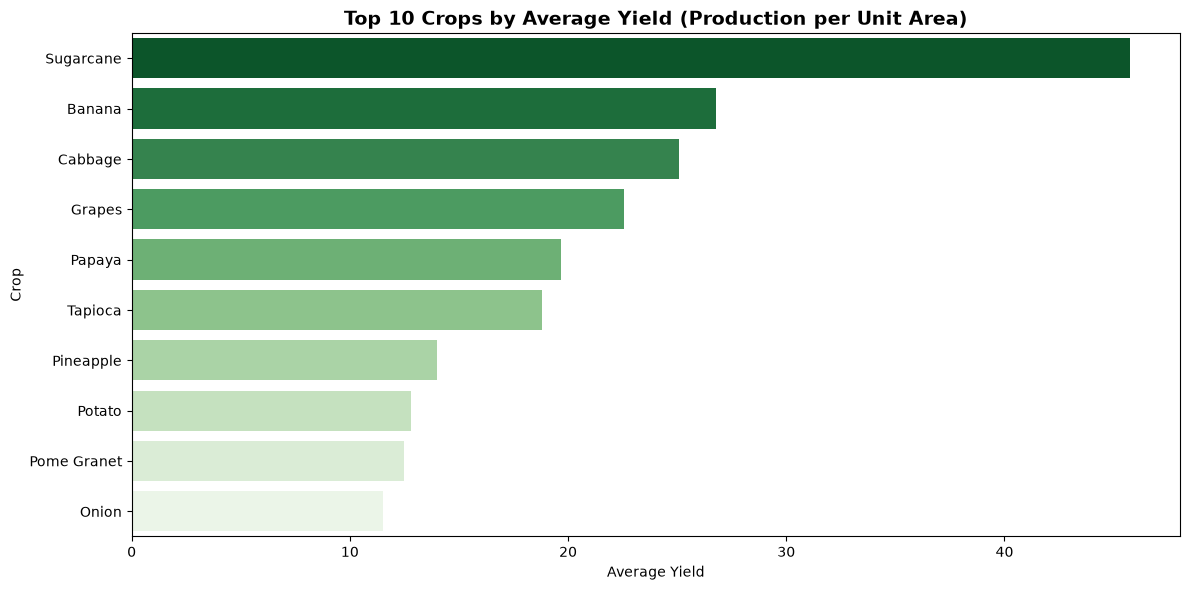

In [ ]:
crop_yield = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=crop_yield.values, y=crop_yield.index, hue=crop_yield.index, palette='Greens_r', legend=False)
plt.title('Top 10 Crops by Average Yield (Production per Unit Area)', fontsize=14, fontweight='bold')
plt.xlabel('Average Yield')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart1_top_crops_yield.png', dpi=150, bbox_inches='tight')
plt.show()

### Regional production comparison

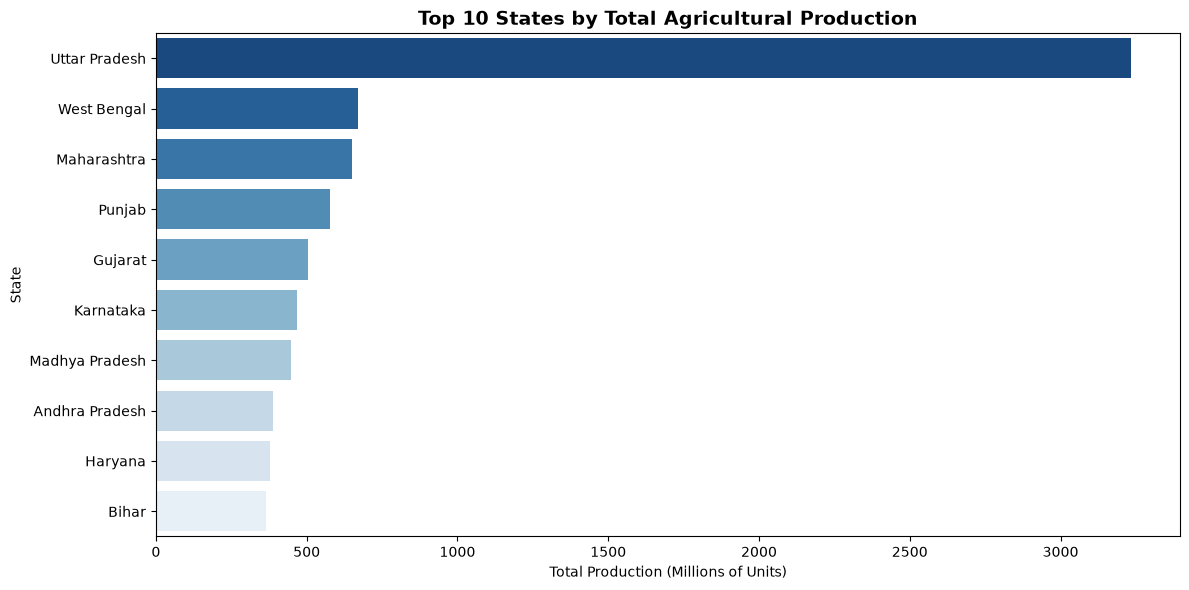

In [ ]:
region_prod = df.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=region_prod.values / 1e6, y=region_prod.index, hue=region_prod.index, palette='Blues_r')
plt.title('Top 10 States by Total Agricultural Production', fontsize=14, fontweight='bold')
plt.xlabel('Total Production (Millions of Units)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('chart2_regional_production.png', dpi=150, bbox_inches='tight')
plt.show()

### Season-wise production comparison

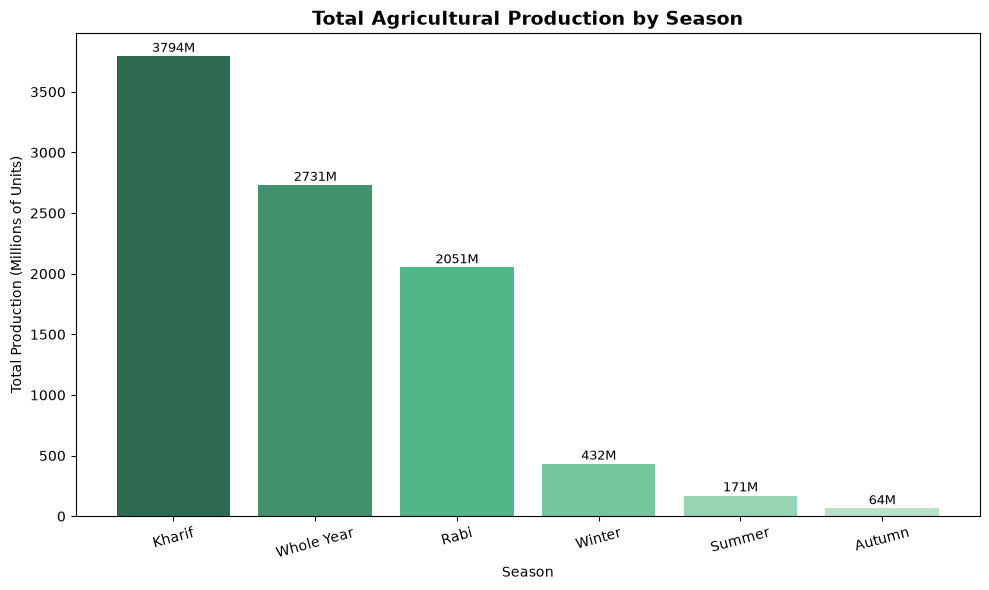

In [ ]:
season_prod = df.groupby('Season')['Production'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2d6a4f','#40916c','#52b788','#74c69d','#95d5b2','#b7e4c7']
bars = plt.bar(season_prod.index, season_prod.values / 1e6, color=colors)
plt.title('Total Agricultural Production by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Total Production (Millions of Units)')
plt.xticks(rotation=15)
for bar, val in zip(bars, season_prod.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val/1e6:.0f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('chart3_season_production.png', dpi=150, bbox_inches='tight')
plt.show()

# Machine Learning & Evaluation
### Building a classification model

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

These libraries are imported to support the machine learning workflow. 
They include tools for preprocessing categorical data, splitting the dataset into training and testing sets, building a classification model using a Random Forest algorithm, and evaluating model performance using standard metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
top_crops = df['Crop'].value_counts().head(10).index
df_ml = df[df['Crop'].isin(top_crops)].copy()
print(f'ML dataset size: {df_ml.shape}')
print(f'Crops: {list(df_ml["Crop"].unique())}')

# Encode categorical columns into numbers
le_state = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

df_ml['State_enc'] = le_state.fit_transform(df_ml['State_Name'])
df_ml['Season_enc'] = le_season.fit_transform(df_ml['Season'])
df_ml['Crop_enc'] = le_crop.fit_transform(df_ml['Crop'])

# Define features (X) and target (y)
X = df_ml[['State_enc', 'Season_enc', 'Area', 'Production', 'Yield']]
y = df_ml['Crop_enc']

print('Features:', X.columns.tolist())
print('Target: Crop (encoded)')

ML dataset size: (94757, 8)
Crops: ['Rice', 'Maize', 'Moong(Green Gram)', 'Urad', 'Arhar/Tur', 'Groundnut', 'Gram', 'Wheat', 'Sesamum', 'Rapeseed &Mustard']
Features: ['State_enc', 'Season_enc', 'Area', 'Production', 'Yield']
Target: Crop (encoded)


This section prepares the dataset for machine learning by selecting the top crop categories, filtering the data accordingly, and encoding categorical variables into numerical form. It then defines the feature set (state, season, area, production, yield) and the target variable (crop type) to be used for model training.

### Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (75805, 5)
Test set: (18952, 5)


This step splits the dataset into training and testing sets, allocating 80% of the data for model training and 20% for evaluation. This ensures that the model is tested on unseen data to assess its ability to generalise, and the dataset shapes are printed to confirm the split.


### Model v1 — Base Random Forest

In [ ]:
model_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v1.fit(X_train, y_train)
y_pred_v1 = model_v1.predict(X_test)
acc_v1 = accuracy_score(y_test, y_pred_v1)
print(f'Model v1 Accuracy: {acc_v1:.4f}')

Model v1 Accuracy: 0.6644


This step initializes a Random Forest classifier with 100 decision trees and trains it using the training dataset. The trained model is then used to predict crop types on the test data, and its performance is evaluated using accuracy to measure the proportion of correct predictions.


The first version v1 of our model has a 66.4% accuracy.

### Model v2 — Improved Random Forest

**Improvement:** Increased trees to 200, added max_depth=20 and min_samples_split=5 to reduce overfitting.

In [ ]:
model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
model_v2.fit(X_train, y_train)
y_pred_v2 = model_v2.predict(X_test)
acc_v2 = accuracy_score(y_test, y_pred_v2)
print(f'Model v2 Accuracy: {acc_v2:.4f}')
print(f'Improvement: +{(acc_v2 - acc_v1)*100:.2f}%')

Model v2 Accuracy: 0.6766
Improvement: +1.22%


Accuracy improved from 66.4% in the v1 to 67.7% in the v2 of our models because in addition to doubling trees, we limited how deep and how specific the model was allowed to get, so it would learn general patterns rather than memorizing quirks in the training data.

### Evaluation — Classification Report

In [ ]:
print('Classification Report (Model v2):')
print(classification_report(y_test, y_pred_v2, target_names=le_crop.classes_))

Classification Report (Model v2):
                   precision    recall  f1-score   support

        Arhar/Tur       0.53      0.55      0.54      1513
             Gram       0.68      0.70      0.69      1452
        Groundnut       0.60      0.60      0.60      1729
            Maize       0.73      0.73      0.73      2725
Moong(Green Gram)       0.56      0.56      0.56      1912
Rapeseed &Mustard       0.70      0.72      0.71      1527
             Rice       0.86      0.81      0.83      2996
          Sesamum       0.60      0.65      0.62      1656
             Urad       0.53      0.53      0.53      1877
            Wheat       0.85      0.85      0.85      1565

         accuracy                           0.68     18952
        macro avg       0.67      0.67      0.67     18952
     weighted avg       0.68      0.68      0.68     18952



The classification report breaks our 68% overall accuracy down by individual crop, since one overall number can hide where the model actually struggles.

Rice (f1: 0.83) and Wheat (f1: 0.85) were predicted most reliably, likely because they have more distinct growing patterns in the data. Arhar/Tur (f1: 0.54) and
Urad (f1: 0.53) were the hardest to predict correctly, suggesting these crops are grown under similar conditions (state, season, area) that the model struggles to
tell apart. This tells us the model is genuinely learning patterns, not just guessing, but its confidence should be treated differently depending on the crop.

### Feature Importance

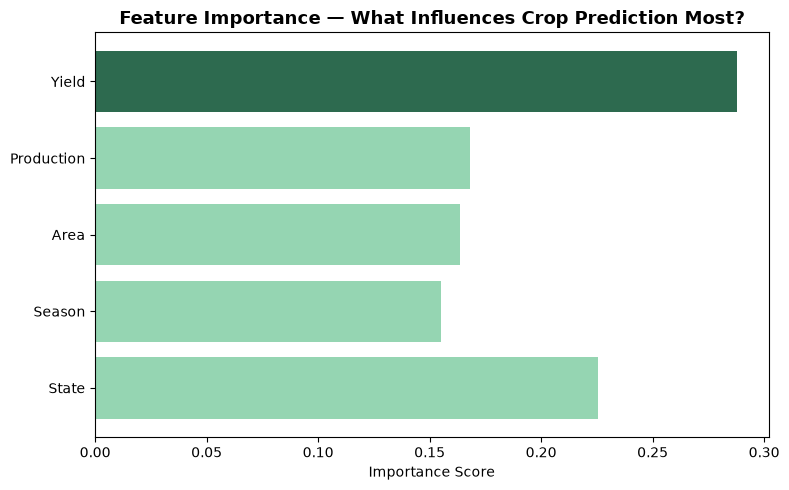

In [ ]:
feature_names = ['State', 'Season', 'Area', 'Production', 'Yield']
importances = model_v2.feature_importances_

plt.figure(figsize=(8, 5))
colors = ['#2d6a4f' if i == np.argmax(importances) else '#95d5b2' for i in range(len(importances))]
plt.barh(feature_names, importances, color=colors)
plt.title('Feature Importance — What Influences Crop Prediction Most?', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

To understand what actually drives the model's crop predictions, we examined feature importance from Model v2. Yield (0.29) and State (0.23) were the two leading features, more influential than Production, Area, or Season. This is notable because State was not something we expected to matter this much, it suggests that different states tend to specialize in different crops due to soil, climate, and regional farming practices, and the model is genuinely picking up on that pattern rather than relying mainly on raw production or area figures.

## Story & Key Findings

---

### The Story: What Does India's Crop Data Tell Us?

**The Problem:** India feeds over a billion people. Understanding which crops grow where, when, and how productively is critical for food security planning.

**What We Found:**

- **Production is concentrated, not spread out.** Uttar Pradesh alone produces more than West Bengal, Maharashtra, and Punjab combined, making national food supply heavily dependent on a single state.
- **The most-grown crops aren't the most efficient ones.** Sugarcane, Banana, and Cabbage top the yield rankings, well above staples like Rice and Wheat, which are common but not especially land-efficient.
- **Geography genuinely shapes what gets grown.** Our model ranked State as the second most influential factor in predicting crop type, right behind Yield itself, confirming that regional conditions (soil, irrigation, tradition) matter more than we initially expected.

## Recommendations

1. **Diversify production geography.** Heavy dependence on Uttar Pradesh is a supply risk. Investing in production capacity in the next-tier states would reduce the country's exposure to regional shocks.
2. **Study what makes high-yield crops efficient**, and evaluate whether any of those practices can reasonably transfer to staple grain regions, without assuming Rice and Wheat can simply be replaced, since food security depends on staples specifically.
3. **Use yield data by season and crop type when planning**, not by production volume alone, since the most commonly grown crop isn't always the most efficient use of land.